In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
import glob

In [ ]:
# sesuaikan nomor atau nama foldernya
# INPUT_DIR = path_reguler_gabungan = '/content/drive/MyDrive/Machine Learning I/UAS/github/3/'
INPUT_DIR = path_reguler_gabungan = '/content/drive/MyDrive/Machine Learning I/UAS/roboflow/1'
# untuk github
OUTPUT_DIR = "/content/drive/MyDrive/Machine Learning I/UAS/QC/roboflow/1/dataset_standard"   # folder untuk hasil yang LAYAK & SUDAH DI-RESIZE
LOG_DIR = "/content/drive/MyDrive/Machine Learning I/UAS/QC/roboflow/1/dataset_tidak_layak" # folder untuk menampung gambar yang terlalu kecil

# untuk auto
# OUTPUT_DIR = "/content/drive/MyDrive/Machine Learning I/UAS/QC/8/dataset_standard"   # folder untuk hasil yang LAYAK & SUDAH DI-RESIZE
# LOG_DIR = "/content/drive/MyDrive/Machine Learning I/UAS/QC/8/dataset_tidak_layak" # folder untuk menampung gambar yang terlalu kecil

In [ ]:
# parameter standarisasi (berdasarkan analisis kriteria minimum OCR)
TARGET_WIDTH = 144
TARGET_HEIGHT = 48
MIN_HEIGHT_THRESHOLD = 40  # gambar dengan tinggi di bawah 40px akan dianggap TIDAK LAYAK

In [ ]:
# buat folder jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

In [ ]:
data_log = []

# baca semua file gambar
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_files = [f for f in os.listdir(INPUT_DIR) if Path(f).suffix.lower() in image_extensions]

In [ ]:
for img_name in image_files:
    img_path = os.path.join(INPUT_DIR, img_name)

    # Baca gambar menggunakan OpenCV
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Ambil dimensi asli
    h_orig, w_orig, _ = img.shape
    aspect_ratio = w_orig / h_orig

    # Cek Kelayakan berdasarkan Batas Minimum Resolusi
    if h_orig < MIN_HEIGHT_THRESHOLD:
        status = "TIDAK LAYAK (Terlalu Kecil)"
        # Simpan ke folder tidak layak untuk dokumentasi
        cv2.imwrite(os.path.join(LOG_DIR, img_name), img)
    else:
        status = "LAYAK"

        # PILIH METODE INTERPOLASI YANG BIJAK
        # Jika gambar asli lebih besar dari target -> Gunakan INTER_AREA (Mencegah moiré)
        if h_orig > TARGET_HEIGHT:
            interpolation_method = cv2.INTER_AREA
        # Jika gambar asli lebih kecil tapi lolos threshold -> Gunakan INTER_CUBIC (Menjaga ketajaman)
        else:
            interpolation_method = cv2.INTER_CUBIC

        # Eksekusi Resize
        resized_img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=interpolation_method)

        # Simpan ke folder dataset standar
        cv2.imwrite(os.path.join(OUTPUT_DIR, img_name), resized_img)

    # Catat data ke log untuk analisis statistik
    data_log.append({
        "Nama_File": img_name,
        "Lebar_Asli": w_orig,
        "Tinggi_Asli": h_orig,
        "Rasio_Asli": round(aspect_ratio, 2),
        "Status": status
    })

In [ ]:
df = pd.DataFrame(data_log)
print("[+] Proses selesai!")

[+] Proses selesai!


In [ ]:
df.head()

,Nama_File,Lebar_Asli,Tinggi_Asli,Rasio_Asli,Status
0,crop_0_BE4467XJ_jpg.rf.dd3654cddec99cd2df4ba94...,283,93,3.04,LAYAK
1,crop_0_BE4717AE_jpg.rf.51287c0ab5e7be27d4aec9a...,190,87,2.18,LAYAK
2,crop_0_BE4038FJ_jpg.rf.63067663c1c0a8609f3ceb3...,324,110,2.95,LAYAK
3,crop_0_BE3494KN_jpg.rf.44b05c4698fffbdc778a60c...,375,132,2.84,LAYAK
4,crop_0_BE1448YL_jpg.rf.3bc37b3382cdfb466797bc1...,484,142,3.41,LAYAK


In [ ]:
df[df['Status'] == 'TIDAK LAYAK (Terlalu Kecil)']

,Nama_File,Lebar_Asli,Tinggi_Asli,Rasio_Asli,Status


In [ ]:
print(df["Status"].value_counts())

Status
LAYAK    38
Name: count, dtype: int64


In [ ]:
print("\n=== STATISTIK DESKRIPTIF DIMENSI ASLI ===")
print(df[["Lebar_Asli", "Tinggi_Asli", "Rasio_Asli"]].describe())


=== STATISTIK DESKRIPTIF DIMENSI ASLI ===
       Lebar_Asli  Tinggi_Asli  Rasio_Asli
count   38.000000    38.000000   38.000000
mean   281.342105   110.684211    2.656316
std     88.422596    44.449245    0.592892
min    102.000000    53.000000    1.570000
25%    216.500000    86.250000    2.007500
50%    283.500000    99.500000    2.830000
75%    330.750000   118.250000    3.062500
max    484.000000   242.000000    3.590000


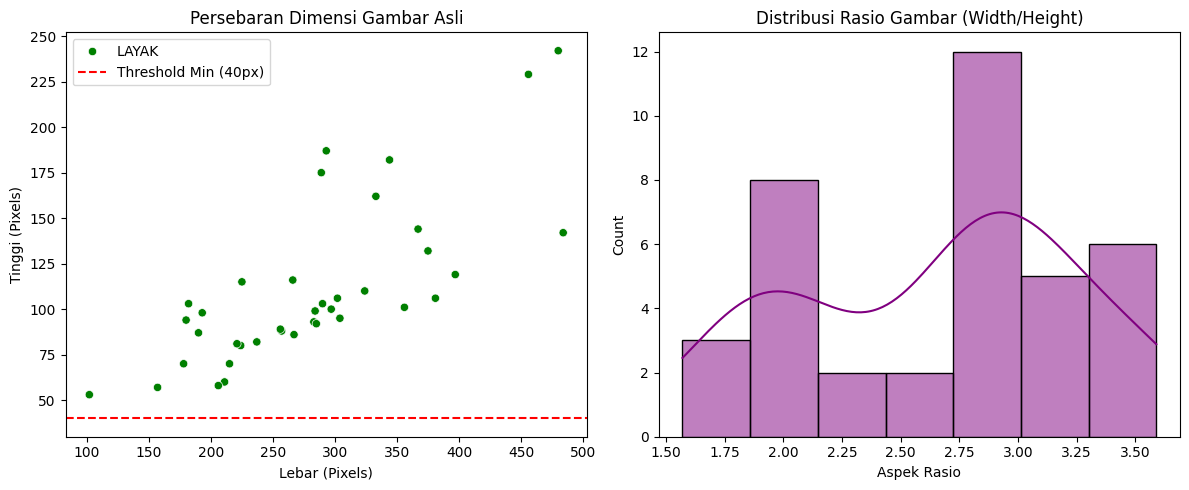

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Lebar_Asli", y="Tinggi_Asli", hue="Status", palette={"LAYAK": "green", "TIDAK LAYAK (Terlalu Kecil)": "red"})
plt.axhline(y=MIN_HEIGHT_THRESHOLD, color='r', linestyle='--', label=f'Threshold Min ({MIN_HEIGHT_THRESHOLD}px)')
plt.title("Persebaran Dimensi Gambar Asli")
plt.xlabel("Lebar (Pixels)")
plt.ylabel("Tinggi (Pixels)")
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df["Rasio_Asli"], kde=True, color="purple")
plt.title("Distribusi Rasio Gambar (Width/Height)")
plt.xlabel("Aspek Rasio")

plt.tight_layout()
plt.show()

In [ ]:
# Define the base root directory where your 'auto_X' folders are located
BASE_ROOT_DIR = '/content/drive/MyDrive/Machine Learning I/UAS/'

# Define image extensions
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

# Find all 'auto_X' folders
auto_folders = sorted(glob.glob(os.path.join(BASE_ROOT_DIR, 'auto_*')))

print("### Image Count per 'auto_X' Folder ###")
total_image_count = 0

for folder_path in auto_folders:
    folder_name = Path(folder_path).name

    # List files in the current folder and filter for image extensions
    image_files_in_folder = [f for f in os.listdir(folder_path) if Path(f).suffix.lower() in image_extensions]

    count = len(image_files_in_folder)
    total_image_count += count
    print(f"Folder '{folder_name}': {count} images")

print(f"\nTotal images across all 'auto_X' folders: {total_image_count}")

### Image Count per 'auto_X' Folder ###
Folder 'auto_1': 252 images
Folder 'auto_2': 47 images
Folder 'auto_3': 45 images
Folder 'auto_4': 141 images
Folder 'auto_5': 12 images
Folder 'auto_6': 16 images
Folder 'auto_7': 34 images
Folder 'auto_8': 70 images
Folder 'auto_9': 161 images

Total images across all 'auto_X' folders: 778


In [ ]:
import os
from pathlib import Path

# Define the QC root directory
QC_ROOT_DIR = '/content/drive/MyDrive/Machine Learning I/UAS/QC'

# Image extensions to look for
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

print(f"### Quality Control Analysis: {QC_ROOT_DIR} ###\n")

# Walk through the QC directory
for root, dirs, files in os.walk(QC_ROOT_DIR):
    # We are interested in folders that contain 'dataset_standard' or 'dataset_tidak_layak'
    if 'dataset_standard' in dirs or 'dataset_tidak_layak' in dirs:
        folder_group = Path(root).name

        # Count standard (LAYAK)
        standard_path = os.path.join(root, 'dataset_standard')
        count_layak = 0
        if os.path.exists(standard_path):
            count_layak = len([f for f in os.listdir(standard_path) if Path(f).suffix.lower() in image_extensions])

        # Count tidak layak
        tidak_layak_path = os.path.join(root, 'dataset_tidak_layak')
        count_tidak_layak = 0
        if os.path.exists(tidak_layak_path):
            count_tidak_layak = len([f for f in os.listdir(tidak_layak_path) if Path(f).suffix.lower() in image_extensions])

        total = count_layak + count_tidak_layak

        print(f"Group: {folder_group}")
        print(f"  - LAYAK       : {count_layak}")
        print(f"  - TIDAK LAYAK : {count_tidak_layak}")
        print(f"  - Total       : {total}")
        print("-" * 30)

### Quality Control Analysis: /content/drive/MyDrive/Machine Learning I/UAS/QC ###

Group: 1
  - LAYAK       : 252
  - TIDAK LAYAK : 0
  - Total       : 252
------------------------------
Group: 2
  - LAYAK       : 47
  - TIDAK LAYAK : 0
  - Total       : 47
------------------------------
Group: 3
  - LAYAK       : 45
  - TIDAK LAYAK : 0
  - Total       : 45
------------------------------
Group: 7
  - LAYAK       : 33
  - TIDAK LAYAK : 1
  - Total       : 34
------------------------------
Group: 4
  - LAYAK       : 140
  - TIDAK LAYAK : 1
  - Total       : 141
------------------------------
Group: 5
  - LAYAK       : 12
  - TIDAK LAYAK : 0
  - Total       : 12
------------------------------
Group: 6
  - LAYAK       : 16
  - TIDAK LAYAK : 0
  - Total       : 16
------------------------------
Group: 8
  - LAYAK       : 70
  - TIDAK LAYAK : 0
  - Total       : 70
------------------------------
Group: 9
  - LAYAK       : 160
  - TIDAK LAYAK : 1
  - Total       : 161
-----------------------

In [ ]:
import os
from pathlib import Path

BASE_DATASET_DIR = '/content/drive/MyDrive/Machine Learning I/UAS/ML & DL/dataset'

# Define image extensions
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

print(f"### Image Count in '{BASE_DATASET_DIR}' ###\n")

readable_dir = os.path.join(BASE_DATASET_DIR, 'readable')
unreadable_dir = os.path.join(BASE_DATASET_DIR, 'unreadable')

count_readable = 0
if os.path.exists(readable_dir):
    count_readable = len([f for f in os.listdir(readable_dir) if Path(f).suffix.lower() in image_extensions])

count_unreadable = 0
if os.path.exists(unreadable_dir):
    count_unreadable = len([f for f in os.listdir(unreadable_dir) if Path(f).suffix.lower() in image_extensions])

total_images = count_readable + count_unreadable

print(f"Folder 'readable': {count_readable} images")
print(f"Folder 'unreadable': {count_unreadable} images")
print(f"Total images in dataset: {total_images}")

### Image Count in '/content/drive/MyDrive/Machine Learning I/UAS/ML & DL/dataset' ###

Folder 'readable': 1455 images
Folder 'unreadable': 133 images
Total images in dataset: 1588
